<a href="https://colab.research.google.com/github/oksanayefimova/AES_repo/blob/dev_efcamdat_clean/Fairness_of_scoring_systems_EFCamDat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness of scoring systems: EFCamDat

## Data Parsing

In [2]:
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt


drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# #read the whole dataset
# # you can try) maybe you are luckier than me)
# import pandas as pd
# file_path = '/content/drive/MyDrive/AES_data/EFCAMDAT/EFCAMDAT_Database.xml'
# df = pd.read_xml(file_path)
# df

In [4]:
!head -n 40 /content/drive/MyDrive/AES_data/EFCAMDAT/EFCAMDAT_Database.xml

<?xml version="1.0" encoding="UTF-8"?>
<selection id="633c1c72818c9091e67ae75ce7f0d2fc">
  <meta>
    <title>Education First - Cambridge Open Language Database</title>
    <version>EFCamDat_2.0 (EF201403)</version>
    <url>https://corpus.mml.cam.ac.uk/efcamdat/</url>
    <key>ZHosYW8sYmYsY20sdGQsa20sY2csY2ksZGosZWcsZXQsZ2EsZ20sZ2gsbWcsbWwsbXIsbXUsbWEsbXosbmcsc24semEsc2QsYWYsYW0sYXosYmgsa2gsY24saGssbW8sdHcsY3gsY2MsY3ksZ2UsaW4saWQsaXIsaXEsaWwsanAsam8sa3osa3csa2csbGEsbGIsbXksbW4sbW0sbnAsb20scGsscHMscGgscWEsc2Esc2csa3Isc3ksdGgsdHIsdG0sYWUsdXosdm4seWUsYWwsYXQsYnksYmUsYmEsYmcsaHIsY3osZGssZWUsZmksZnIsZGUsZ3IsZ3AsaHUsaWUsaXQsbHQsbHYsbWssbXQsbWQsbmwsbm8scGwscHQscm8scnUsc2ssc2ksZXMsc2UsY2gsdWEsZ2IsYXcsYnosY2EsY3IsY3UsZG0sZG8sc3YsZ2wsZ3QsaG4sbXgsbmkscGEscHIsdmMsdXMsYXIsYm8sYnIsY2wsY28sZWMscHkscGUsdXksdmUsYXUscGYsbnIsbmMsbnoscGcsd2YscW4scnMscXMsZXIsYWQsYmQsYm0sYnUscXIsbXEsbWUsbHUsYnMsbWMsZWgsdG4saHQsdnUsZ24sY2QsZ3UsZ2YsbXYsbGssdWcsbHksbmUsYWksYmosZmssc3IsdGosaXMsZ3Esc28sdGcsYnQsZm8sYncscW0sencsYX

In [5]:
import pandas as pd
from lxml import etree

file_path = '/content/drive/MyDrive/AES_data/EFCAMDAT/EFCAMDAT_Database.xml'

MIN_WORD_COUNT = 100

print(f"Minimum word count filter: {MIN_WORD_COUNT}")
print(f"Parsing starts...")

parsed_data = []

# Iterative parser allows us to process the entire 1.2GB file without RAM issues
context = etree.iterparse(file_path, events=('end',), tag='writing', recover=True)

for event, elem in context:
    learner_elem = elem.find('learner')
    nationality = learner_elem.get('nationality') if learner_elem is not None else None

    text = elem.findtext('text')

    if text and text.strip():
        clean_text = text.strip()

        if len(clean_text.split()) >= MIN_WORD_COUNT:

            topic_elem = elem.find('topic')
            parsed_data.append({
                'writing_id': elem.get('id'),
                'level': elem.get('level'),
                'unit': elem.get('unit'),
                'learner_id': learner_elem.get('id') if learner_elem is not None else None,
                'nationality': nationality,
                'topic_id': topic_elem.get('id') if topic_elem is not None else None,
                'topic_text': topic_elem.text if topic_elem is not None else None,
                'date': elem.findtext('date'),
                'grade': elem.findtext('grade'),
                'essay_text': clean_text
            })

    # CLEAR MEMORY
    elem.clear()
    while elem.getprevious() is not None:
        del elem.getparent()[0]

df_efcamdat = pd.DataFrame(parsed_data)

print(f"Parsing complete. Successfully extracted {len(df_efcamdat)} informative essays.")

Minimum word count filter: 100
Parsing starts...
Parsing complete. Successfully extracted 45731 informative essays.


In [6]:
df_efcamdat['nationality'].unique()

array(['no', 'mx', 'fr', 'cn', 'co', 'ru', 'br', 'sa', 'es', 'de', 'tw',
       'ng', 'th', 'it', 'kz', 'sv', 'cl', 'uy', 'gt', 'ch', 'kr', 'tr',
       'vn', 'us', 'qn', 'at', 'jp', 'gb', 'pl', 'sy', 'np', 'ae', 'eg',
       'jo', 'ca', 'hk', 'ua', 'cz', 'lt', 'sk', 've', 'pk', 'pr', 'kg',
       'az', 'ye', 'pt', 'ma', 'ro', 'mm', 'pe', 'gp', 'au', 'se', 'do',
       'si', 'id', 'rs', 'vc', 'cu', 'uz', 'ml', 'sg', 'ge', 'ao', 'mu',
       'gr', 'lb', 'bh', 'by', 'nl', 'am', 'hu', 'dk', 'lv', 'ar', 'mo',
       'tm', 'be', 'ph', 'md', 'pf', 'pg', 'fi', 'bg', 'kw', 'dz', 'om',
       'cy', 'ps', 'er', 'qa', 'td', 'mk', 'ga', 'dj', 'ie', 'ee', 'sd',
       'ec', 'cr', 'mn', 'in', 'ba', 'mz', 'my', 'iq', 'hr', 'mc', 'mq',
       'ci', 'il', 'pa', 'vu', 'mg', 'lu', 'nz', 'al', 'nc', 'ad', 'bo',
       'ug', 'kh', 'ht', 'ly', 'fk', 'mt', 'bj', 'py', 'sr', 'ir', 'tj',
       'cm', 'gq', 'bm', 'ni', 'bu', 'cc', 'fo', 'sn', 'tn', 'la', 'hn',
       'za', 'af', 'cg', 'cv', 'kp', 'gh', 'sm', 'g

#### Adding calculated columns (Based on the Glossary)

In [7]:
# wordcount
df_efcamdat['wordcount'] = df_efcamdat['essay_text'].apply(lambda x: len(str(x).split()))

# L1 (Native Language) Mapping
l1_mapping = {
    # Spanish
    'mx': 'Spanish', 'co': 'Spanish', 'es': 'Spanish', 'cl': 'Spanish', 'uy': 'Spanish',
    'gt': 'Spanish', 'sv': 'Spanish', 've': 'Spanish', 'pr': 'Spanish', 'pe': 'Spanish',
    'do': 'Spanish', 'cu': 'Spanish', 'ar': 'Spanish', 'ec': 'Spanish', 'cr': 'Spanish',
    'pa': 'Spanish', 'bo': 'Spanish', 'py': 'Spanish', 'ni': 'Spanish', 'hn': 'Spanish', 'gq': 'Spanish',
    # Portuguese
    'br': 'Portuguese', 'pt': 'Portuguese', 'ao': 'Portuguese', 'mz': 'Portuguese', 'cv': 'Portuguese',
    # French
    'fr': 'French', 'gp': 'French', 'ml': 'French', 'pf': 'French', 'td': 'French', 'ga': 'French',
    'dj': 'French', 'mc': 'French', 'mq': 'French', 'ci': 'French', 'nc': 'French', 'ht': 'French',
    'bj': 'French', 'cm': 'French', 'sn': 'French', 'cg': 'French', 'gn': 'French',
    # Arabic
    'sa': 'Arabic', 'sy': 'Arabic', 'ae': 'Arabic', 'eg': 'Arabic', 'jo': 'Arabic', 'ye': 'Arabic',
    'ma': 'Arabic', 'lb': 'Arabic', 'bh': 'Arabic', 'kw': 'Arabic', 'dz': 'Arabic', 'om': 'Arabic',
    'ps': 'Arabic', 'qa': 'Arabic', 'sd': 'Arabic', 'iq': 'Arabic', 'ly': 'Arabic', 'tn': 'Arabic',
    # English
    'us': 'English', 'gb': 'English', 'ng': 'English', 'au': 'English', 'ca': 'English', 'vc': 'English',
    'sg': 'English', 'mu': 'English', 'pg': 'English', 'ie': 'English', 'nz': 'English', 'ug': 'English',
    'fk': 'English', 'bm': 'English', 'cc': 'English', 'za': 'English', 'gh': 'English',
    # Chinese / Mandarin / Cantonese
    'cn': 'Mandarin', 'tw': 'Mandarin', 'hk': 'Cantonese', 'mo': 'Cantonese',
    # German
    'de': 'German', 'at': 'German', 'ch': 'German',
    # Russian & Ukrainian
    'ru': 'Russian', 'by': 'Belorussian', 'ua': 'Ukrainian',
    # Italian
    'it': 'Italian', 'sm': 'Italian',
    # Dutch
    'nl': 'Dutch', 'be': 'Dutch', 'sr': 'Dutch',
    # Romanian
    'ro': 'Romanian', 'md': 'Romanian',
    # Korean & Japanese
    'kr': 'Korean', 'kp': 'Korean', 'jp': 'Japanese',
    # Other Major Languages
    'tr': 'Turkish', 'vn': 'Vietnamese', 'th': 'Thai', 'pl': 'Polish',
    'cz': 'Czech', 'sk': 'Slovak', 'in': 'Hindi', 'pk': 'Urdu',
    'id': 'Indonesian', 'my': 'Malay', 'ph': 'Tagalog', 'gr': 'Greek',
    'cy': 'Greek', 'se': 'Swedish', 'fi': 'Finnish', 'no': 'Norwegian',
    'dk': 'Danish', 'hu': 'Hungarian', 'bg': 'Bulgarian', 'rs': 'Serbian',
    'hr': 'Croatian', 'ba': 'Bosnian', 'si': 'Slovenian', 'mk': 'Macedonian',
    'al': 'Albanian', 'ee': 'Estonian', 'lv': 'Latvian', 'lt': 'Lithuanian',
    'ge': 'Georgian', 'am': 'Armenian', 'az': 'Azerbaijani', 'kz': 'Kazakh',
    'uz': 'Uzbek', 'tm': 'Turkmen', 'kg': 'Kyrgyz', 'tj': 'Tajik',
    'ir': 'Persian', 'af': 'Dari', 'il': 'Hebrew', 'mn': 'Mongolian',
    'mm': 'Burmese', 'bu': 'Burmese', 'kh': 'Khmer', 'la': 'Lao',
    'np': 'Nepali', 'mg': 'Malagasy', 'er': 'Tigrinya', 'mt': 'Maltese',
    'lu': 'Luxembourgish', 'ad': 'Catalan', 'vu': 'Bislama', 'qn': 'Unknown'
}

df_efcamdat['l1'] = df_efcamdat['nationality'].str.lower().map(l1_mapping)

# Convert 1-16 'level'-> CEFR
df_efcamdat['level'] = pd.to_numeric(df_efcamdat['level'], errors='coerce')

# Map the 16 EF proficiency levels to the standard CEFR categories
def get_cefr(lvl):
    if pd.isna(lvl): return None
    if 1 <= lvl <= 3: return 'A1'
    elif 4 <= lvl <= 6: return 'A2'
    elif 7 <= lvl <= 9: return 'B1'
    elif 10 <= lvl <= 12: return 'B2'
    elif 13 <= lvl <= 15: return 'C1'
    elif lvl == 16: return 'C2'
    return None

df_efcamdat['cefr'] = df_efcamdat['level'].apply(get_cefr)

cefr_num_mapping = {'A1': 1, 'A2': 2, 'B1': 3, 'B2': 4, 'C1': 5, 'C2': 6}
df_efcamdat['cefr_numeric'] = df_efcamdat['cefr'].map(cefr_num_mapping)


In [8]:
df_efcamdat["topic_id"].unique()

array(['43', '49', '74', '75', '78', '41', '42', '30', '32', '33', '25',
       '73', '97', '90', '91', '95', '98', '101', '52', '28', '66', '76',
       '46', '64', '36', '37', '51', '44', '50', '53', '54', '55', '57',
       '60', '65', '67', '68', '69', '70', '72', '45', '26', '89', '35',
       '38', '40', '77', '79', '81', '80', '9', '5', '18', '11', '13',
       '34', '83', '84', '86', '29', '58', '59', '62', '82', '87', '93',
       '94', '96', '100', '103', '106', '107', '108', '109', '110', '31',
       '19', '48', '17', '61', '85', '88', '4', '63', '71', '56', '6',
       '99', '47', '92', '124', '125', '126', '102', '104', '105', '112',
       '113', '1', '27', '111', '114', '117', '119', '120', '127', '128',
       '7', '10', '16', '12', '21', '22', '115', '116', '118', '15', '8',
       '122', '39', '121', '23', '2', '123', '3', '14', '20'],
      dtype=object)

In [9]:
df_efcamdat

,writing_id,level,unit,learner_id,nationality,topic_id,topic_text,date,grade,essay_text,wordcount,l1,cefr,cefr_numeric
0,3,6,3,103510,no,43,Creating an office dress code,2011-04-03 04:16:16.137,86,From:xxx@1234.com To:Herman xxx@1234.com Date:...,103,Norwegian,A2,2
1,14,7,1,15037,mx,49,Giving instructions to play a game,2012-07-13 14:00:09.810,92,"the name of the play is run, jump and crawl, w...",115,Spanish,B1,3
2,19,10,2,82909,fr,74,Doing a survey about discrimination,2011-04-20 04:55:25.820,97,What do you know about discrimination at work?...,105,French,B2,4
3,20,10,3,82909,fr,75,Requesting a bank loan,2011-05-02 05:06:36.603,83,"Dir Sir, I would like to buy the flat I am cur...",148,French,B2,4
4,21,10,6,82909,fr,78,Describing a terrifying experience,2011-07-12 05:04:38.813,89,"This story occured few month ago, when a frien...",138,French,B2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45726,1210956,11,5,59085,br,85,Reviewing a self-help book,2014-03-12 10:04:59.493,100,People from Sao Paulo in Brazil smoke hardly b...,165,Portuguese,B2,4
45727,1210966,10,3,134997,gb,75,Requesting a bank loan,2014-03-08 09:38:41.707,100,My dog's financial situation is very good. It ...,140,English,B2,4
45728,1211022,3,7,163921,id,23,Asking a friend to shop for you,2014-03-04 02:34:05.553,100,"Dear Rolf, I'm writing to confirm the arrangem...",102,Indonesian,A1,1
45729,1211024,10,3,163921,id,75,Requesting a bank loan,2014-03-05 07:18:36.797,95,"Dear Sir or Madam, I am writing to enquire abo...",126,Indonesian,B2,4


## Data overview

In [12]:
df_efcamdat['nationality'].value_counts()

,count
nationality,
br,10885
cn,9070
de,4599
ru,4400
it,2613
...,...
cc,1
cg,1
za,1


In [13]:
(df_efcamdat['nationality'].value_counts()>20).sum()

np.int64(62)

In [14]:
df_efcamdat['l1'].value_counts()

,count
l1,
Portuguese,10982
Mandarin,10430
German,5044
Russian,4400
Spanish,3506
...,...
Nepali,1
Bislama,1
Catalan,1


In [15]:
(df_efcamdat['l1'].value_counts()>5).sum()

np.int64(51)

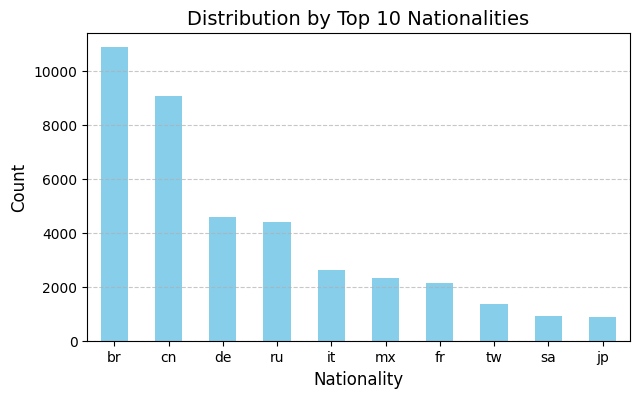

In [16]:
plt.figure(figsize=(7, 4))
nat_counts = df_efcamdat['nationality'].value_counts().head(10)
nat_counts.plot(kind='bar', color='skyblue',)
plt.title('Distribution by Top 10 Nationalities', fontsize=14)
plt.xlabel('Nationality', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

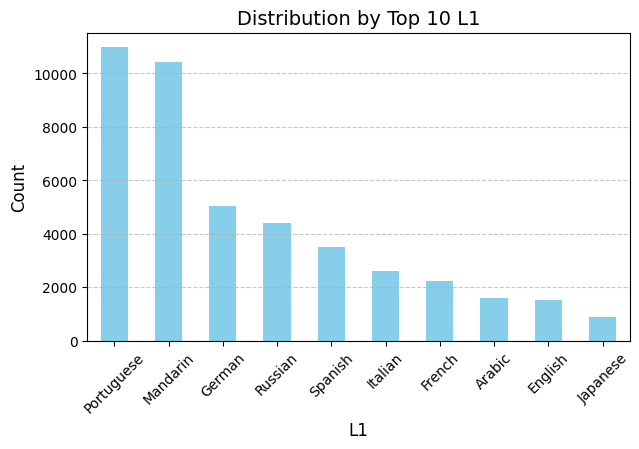

In [17]:
plt.figure(figsize=(7, 4))
nat_counts = df_efcamdat['l1'].value_counts().head(10)
nat_counts.plot(kind='bar', color='skyblue',)
plt.title('Distribution by Top 10 L1', fontsize=14)
plt.xlabel('L1', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
df_efcamdat['cefr'].value_counts()


,count
cefr,
B1,15627
B2,14455
A2,7751
C1,4019
A1,3348
C2,531


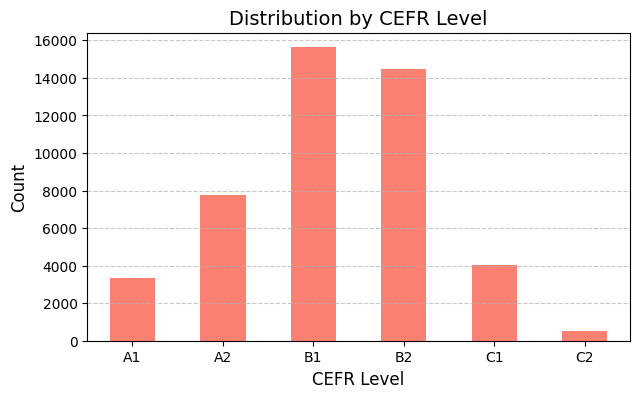

In [19]:
plt.figure(figsize=(7, 4))
cefr_counts = df_efcamdat['cefr'].value_counts().sort_index()
cefr_counts.plot(kind='bar', color='salmon')
plt.title('Distribution by CEFR Level', fontsize=14)
plt.xlabel('CEFR Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
(df_efcamdat['wordcount']>500).sum()

np.int64(16)

In [21]:
(df_efcamdat['wordcount']<100).sum()

np.int64(0)

In [22]:
df_efcamdat['wordcount'].max()

1310

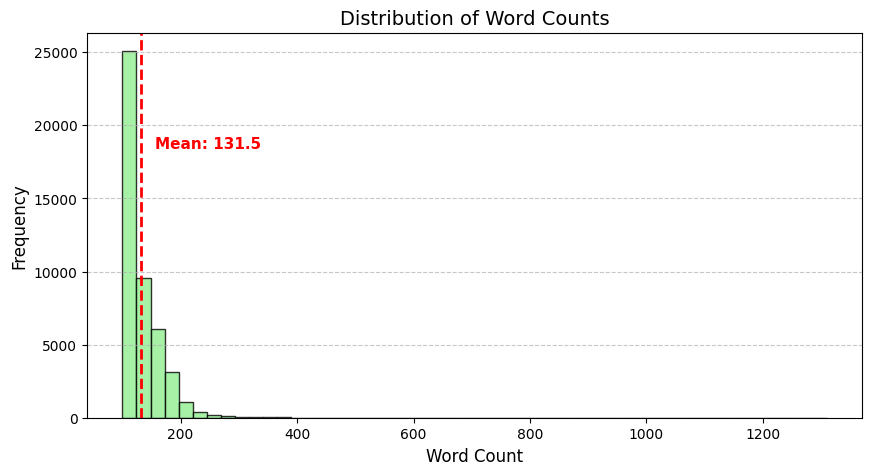

In [23]:
# remove outliers
#df_efcamdat = df_efcamdat[df_efcamdat['wordcount'] <= 500]

plt.figure(figsize=(10, 5))
mean_wc = df_efcamdat['wordcount'].mean()
plt.hist(df_efcamdat['wordcount'], bins=50, color='lightgreen', edgecolor='black', alpha=0.8)
plt.axvline(mean_wc, linestyle='--', color='red', linewidth=2)
plt.text(mean_wc + (df_efcamdat['wordcount'].max() - df_efcamdat['wordcount'].min())*0.02,
         plt.ylim()[1]*0.7,
         s=f"Mean: {round(mean_wc, 1)}", color='red', fontweight='bold', fontsize=11)
plt.title('Distribution of Word Counts', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

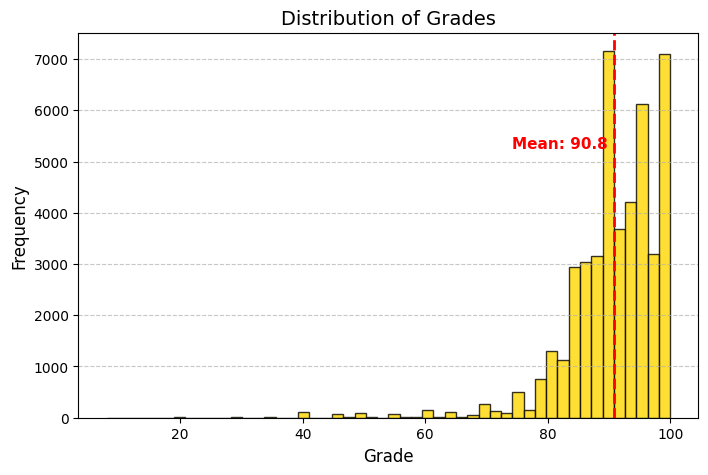

In [24]:
plt.figure(figsize=(8, 5))
df_efcamdat['grade'] = pd.to_numeric(df_efcamdat['grade'], errors='coerce')
mean_grade = df_efcamdat['grade'].mean()
plt.hist(df_efcamdat['grade'].dropna(), bins=50, color='gold', edgecolor='black', alpha=0.8)
plt.axvline(mean_grade, linestyle='--', color='red', linewidth=2)
plt.text(mean_grade - (df_efcamdat['grade'].max() - df_efcamdat['grade'].min())*0.18,
         plt.ylim()[1]*0.7,
         s=f"Mean: {round(mean_grade, 1)}", color='red', fontweight='bold', fontsize=11)
plt.title('Distribution of Grades', fontsize=14)
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Filtering

In [31]:
df_efcamdat['topic_text'].unique()

array(['Creating an office dress code',
       'Giving instructions to play a game',
       'Doing a survey about discrimination', 'Requesting a bank loan',
       'Describing a terrifying experience', 'Writing a movie plot',
       'Filling in an arrival card', 'Writing an autobiography',
       'Describing people in photos',
       'Planning to attend a music festival', 'Writing about what you do',
       'Helping a friend find a job', 'Writing a campaign speech',
       'Entering a writing competition', 'Buying a painting for a friend',
       'Conducting a performance appraisal', 'Renting out a room',
       'Writing about a disaster relief effort',
       'Writing about a memorable experience',
       'Writing about what you like doing', 'Studying online',
       'Applying to be a fitness trainer', 'Writing an email of advice',
       'Claiming back your security deposit',
       'Giving instructions to a house-sitter',
       'Filling out an insurance claim form',
       'Writing

### Filtering topics
Thoroughly observed the topics, we should filter ones most connected to essays.

In [42]:
target_tasks = ['Comparing two demographic groups',
                'Writing up survey findings',
                'Writing a report on staff satisfaction',
                'Comparing two online retailers',
                'Writing about future lifestyles',
                'Choosing a renewable energy source',
                'Doing a survey about discrimination',
                'Writing a movie review',
                'Reviewing a self-help book',
                'Writing a blog',
                'Writing an article about NLP techniques',
                'Writing an article about a superstore',
                'Writing about a disaster relief effort',
                'Writing a campaign speech',
                'Writing about a memorable experience',
                'Planning for the future',
                'Studying online'
                ]


df_essays = df_efcamdat[df_efcamdat['topic_text'].isin(target_tasks)]
df_essays['cefr'].value_counts()

,count
cefr,
B1,4413
B2,3453
C1,1733


### Filtering L1

In [43]:
ct = pd.crosstab(df_essays['l1'], df_essays['cefr'])
ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

cefr,B1,B2,C1
l1,,,
Portuguese,1089,964,440
Mandarin,1113,404,121
German,349,496,317
Russian,458,370,181
Spanish,326,305,126
Italian,276,218,121
French,230,166,95
English,115,136,108
Arabic,152,99,76


In [45]:
valid_l1 = [
    'Portuguese', 'Mandarin', 'German', 'Russian', 'Spanish',
    'Italian', 'French', 'English', 'Arabic', 'Japanese', 'Turkish'
]

df_final = df_essays[df_essays['l1'].isin(valid_l1)]
df_final

,writing_id,level,unit,learner_id,nationality,topic_id,topic_text,date,grade,essay_text,wordcount,l1,cefr,cefr_numeric
2,19,10,2,82909,fr,74,Doing a survey about discrimination,2011-04-20 04:55:25.820,97,What do you know about discrimination at work?...,105,French,B2,4
8,70,10,2,135453,ru,74,Doing a survey about discrimination,2011-03-24 18:32:09.590,96,When were you hired? What position did you wan...,111,Russian,B2,4
17,259,13,1,119037,br,97,Writing a campaign speech,2011-05-18 19:15:54.900,88,Hi! My name is Alice Santos. I'm here tonight ...,168,Portuguese,C1,5
21,265,13,1,64152,br,97,Writing a campaign speech,2012-06-08 17:13:45.697,89,Hello all. Good morning. First off I would lik...,177,Portuguese,C1,5
23,269,13,5,64152,br,101,Writing about a disaster relief effort,2012-06-29 20:50:20.967,85,Carson Country Needs You! Recently your city w...,158,Portuguese,C1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45701,1208097,11,5,136015,br,85,Reviewing a self-help book,2014-03-09 13:42:28.037,100,Yesterday we celebrated the Woman's Internatio...,151,Portuguese,B2,4
45704,1208105,13,1,136015,br,97,Writing a campaign speech,2014-03-17 22:44:54.370,95,I will talk about my brother. My brother didn'...,106,Portuguese,C1,5
45717,1210596,9,2,25952,jp,66,Studying online,2014-02-27 05:23:54.083,95,I took the lead at the negotiation with comput...,104,Japanese,B1,3
45721,1210693,10,2,72560,jp,74,Doing a survey about discrimination,2014-03-04 05:07:33.273,100,Gender difference is still an important factor...,137,Japanese,B2,4


### Length Bias Check

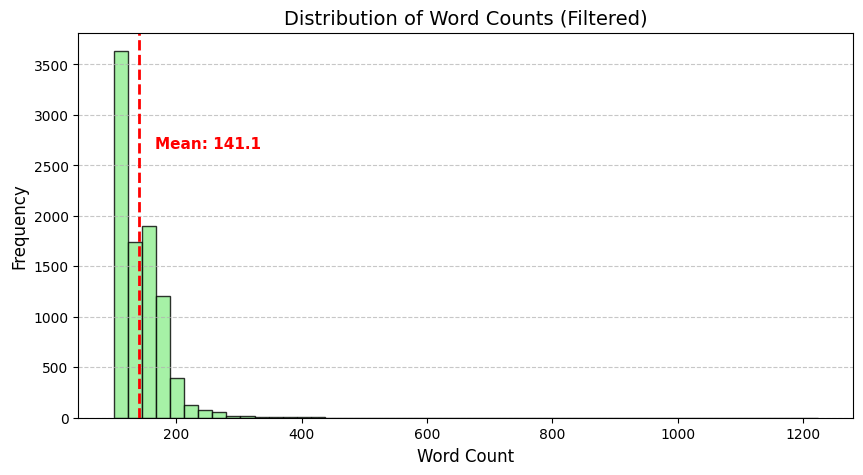

In [46]:
plt.figure(figsize=(10, 5))
mean_wc = df_final['wordcount'].mean()
plt.hist(df_final['wordcount'], bins=50, color='lightgreen', edgecolor='black', alpha=0.8)
plt.axvline(mean_wc, linestyle='--', color='red', linewidth=2)
plt.text(mean_wc + (df_efcamdat['wordcount'].max() - df_efcamdat['wordcount'].min())*0.02,
         plt.ylim()[1]*0.7,
         s=f"Mean: {round(mean_wc, 1)}", color='red', fontweight='bold', fontsize=11)
plt.title('Distribution of Word Counts (Filtered)', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [49]:
df_final.groupby(['cefr', 'l1'])['wordcount'].mean().unstack()

l1,Arabic,English,French,German,Italian,Japanese,Mandarin,Portuguese,Russian,Spanish,Turkish
cefr,,,,,,,,,,,
B1,134.967105,141.034783,133.656522,131.148997,131.956522,128.527027,139.768194,130.062443,133.058952,130.420245,131.968750
B2,133.626263,134.205882,135.680723,135.588710,137.793578,127.961538,142.517327,135.270747,132.643243,134.573770,129.027027
C1,188.684211,165.388889,165.021053,173.529968,175.553719,166.000000,178.264463,166.275000,171.629834,165.063492,172.793103


### Filtering essays on L1 and level

In [50]:
df_limited = df_final.groupby(['l1', 'cefr']).apply(lambda x: x.sample(n=min(len(x), 100), random_state=1111)).reset_index(drop=True)

print(pd.crosstab(df_limited['l1'], df_limited['cefr']))

cefr         B1   B2   C1
l1                       
Arabic      100   99   76
English     100  100  100
French      100  100   95
German      100  100  100
Italian     100  100  100
Japanese     74  100   46
Mandarin    100  100  100
Portuguese  100  100  100
Russian     100  100  100
Spanish     100  100  100
Turkish      64   37   29


/tmp/ipykernel_7342/3737956677.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_limited = df_final.groupby(['l1', 'cefr']).apply(


### Converting grades to the ICNALE scale (/12)

In [58]:
df_limited['grade (/12)'] = df_limited['grade']*0.12
df_limited

,writing_id,level,unit,learner_id,nationality,topic_id,topic_text,date,grade,essay_text,wordcount,l1,cefr,cefr_numeric,grade (/12)
0,262678,9,2,149073,ps,66,Studying online,2012-09-22 18:52:16.653,97,"Hello Robert, First off, I'd like to say thank...",180,Arabic,B1,3,11.64
1,197509,9,8,154485,eg,72,Writing a blog,2011-11-07 08:58:41.503,84,"Hi! This is Mina Kiriakos, I'm from Egypt. I w...",110,Arabic,B1,3,10.08
2,55820,7,2,14811,sy,50,Planning for the future,2011-07-20 20:34:05.670,87,I'm going to graduate within 6 months from med...,112,Arabic,B1,3,10.44
3,416073,7,4,89040,sd,52,Writing about a memorable experience,2012-04-14 17:06:44.133,100,"Hello, It seems like you both had a great time...",116,Arabic,B1,3,12.00
4,874785,7,2,156223,sa,50,Planning for the future,2013-09-30 14:33:09.953,100,"Dear Hind, I got my degree in English literatu...",142,Arabic,B1,3,12.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,264981,13,5,71612,tr,101,Writing about a disaster relief effort,2011-12-18 14:04:38.950,82,Carson County Needs You! Hurricane Melinda has...,119,Turkish,C1,5,9.84
3016,328343,13,1,138106,tr,97,Writing a campaign speech,2012-03-15 18:07:43.060,89,"Hi , I don't have enough time to write a big e...",160,Turkish,C1,5,10.68
3017,128116,13,1,62531,tr,97,Writing a campaign speech,2011-08-01 19:45:14.427,96,good morning everybody.i am mehmet etin.i am t...,124,Turkish,C1,5,11.52
3018,510760,13,5,111116,tr,101,Writing about a disaster relief effort,2012-09-09 03:09:53.097,83,Carson County Needs You! We had a big earthqua...,192,Turkish,C1,5,9.96


Text(0.5, 1.0, 'Topic Distribution')

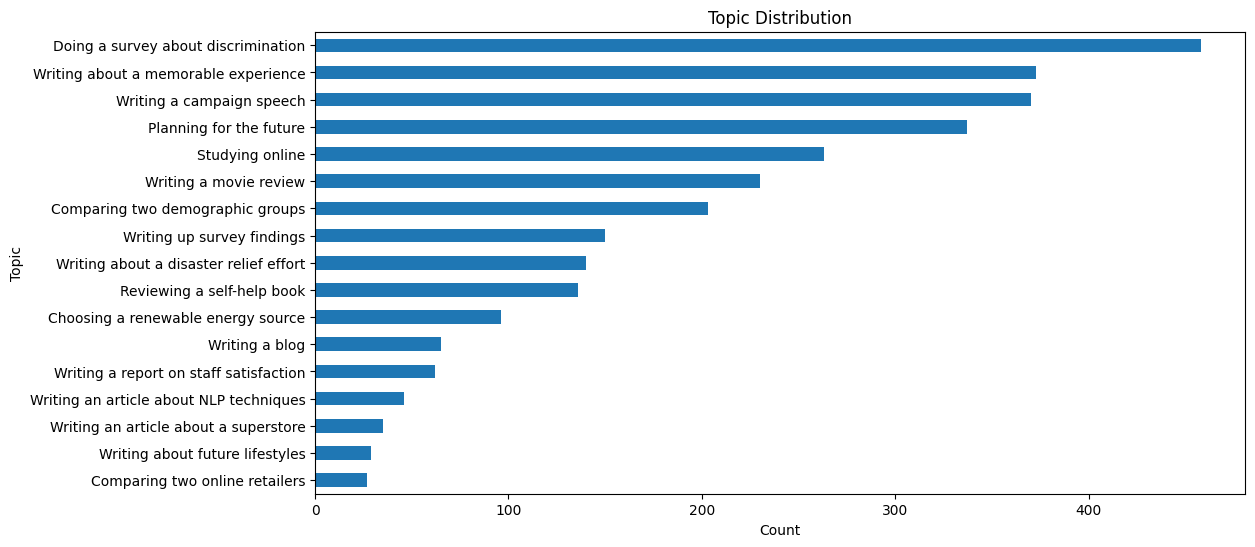

In [70]:
topic_dist = df_limited['topic_text'].value_counts().sort_values(ascending=True)
topic_dist.plot(kind='barh', figsize=(12, 6))
plt.xlabel("Count")
plt.ylabel('Topic')
plt.title('Topic Distribution')

Text(0.5, 1.0, 'Topic/L1 Heatmap')

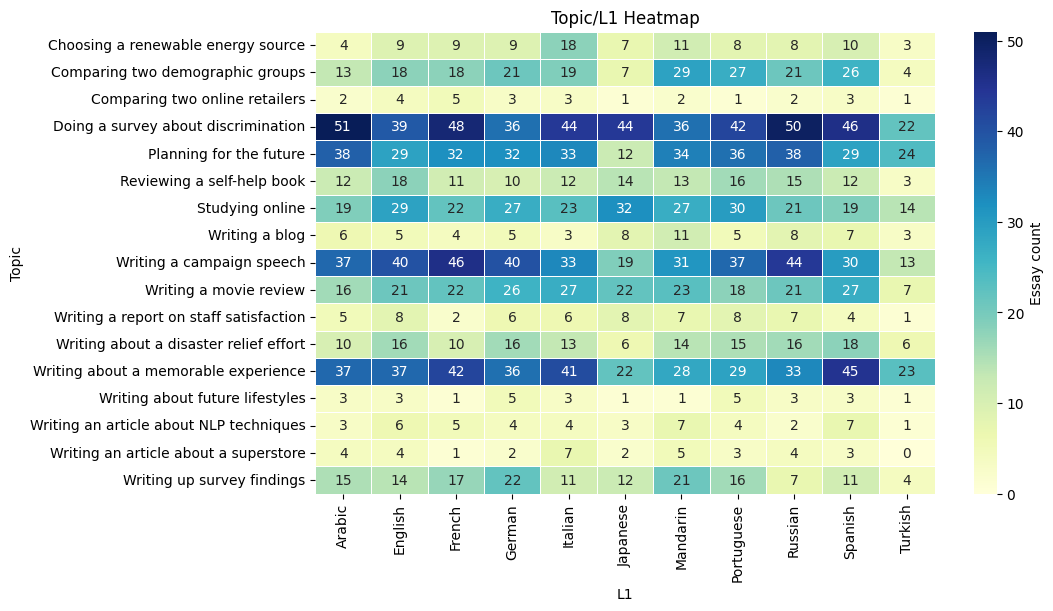

In [76]:
import seaborn as sns

pivot_matrix = pd.crosstab(df_limited['topic_text'], df_limited['l1'])
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Essay count'}
)

plt.xlabel("L1")
plt.ylabel("Topic")
plt.title('Topic/L1 Heatmap')

As we see the heatmap is horizontally distributed which means we do not have some leader-countries. We can regard this filtering as complete.